### data check and preprocessing

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.model_selection import train_test_split
import math


In [38]:
from datetime import datetime

In [40]:
Bitcoin_data =pd.read_csv('data/Bitcoin.csv') # 비트코인 데이터 확인
Bitcoin_data = Bitcoin_data.drop(['시가','고가','저가','거래량','변동 %'], axis=1)   # 필요한 데이터 종가와 날짜만을 가지고 옴
Bitcoin_data = Bitcoin_data.rename(columns={'종가':'bitcoin'}) # 열이름 변경
Bitcoin_data = Bitcoin_data.assign(날짜=pd.to_datetime(Bitcoin_data['날짜'], format="%Y년 %m월 %d일"))
Bitcoin_data['날짜'] = Bitcoin_data['날짜'].dt.strftime("%Y-%m-%d")
print(Bitcoin_data.head(10))

           날짜   bitcoin
0  2023-04-30  29,252.1
1  2023-04-29  29,234.1
2  2023-04-28  29,321.8
3  2023-04-27  29,475.9
4  2023-04-26  28,424.6
5  2023-04-25  28,298.8
6  2023-04-24  27,509.3
7  2023-04-23  27,591.4
8  2023-04-22  27,813.9
9  2023-04-21  27,264.8


In [35]:
Gold_data = pd.read_csv('data/gold.csv',encoding = 'ISO-8859-1') # 골드데이터 확인
Gold_data = Gold_data.rename(columns={'³¯Â¥':'날짜'})
Gold_data = Gold_data.rename(columns={'US dollar':'gold'})
print(Gold_data.head(10))

           날짜   gold
0  1978-12-29    226
1  1979-01-01    226
2  1979-01-02  226.8
3  1979-01-03  218.6
4  1979-01-04  223.2
5  1979-01-05  225.5
6  1979-01-08  223.1
7  1979-01-09    224
8  1979-01-10  220.7
9  1979-01-11  220.7


In [29]:
SP500_data = pd.read_csv('data/SP500.csv') # S&P500 데이터 확인
SP500_data = SP500_data.replace("- ","-",regex=True) #날짜 형식을 맞춤
SP500_data = SP500_data.drop(['시가','고가','저가','거래량','변동 %'], axis=1)   # 필요한 데이터 종가와 날짜만을 가지고 옴
SP500_data = SP500_data.rename(columns={'종가':'SP500'}) # 열이름 변경
print(SP500_data.head(10))

           날짜     SP500
0  2023-04-28  4,169.48
1  2023-04-27  4,135.35
2  2023-04-26  4,055.99
3  2023-04-25  4,071.63
4  2023-04-24  4,137.04
5  2023-04-21  4,133.52
6  2023-04-20  4,129.79
7  2023-04-19  4,154.52
8  2023-04-18  4,154.87
9  2023-04-17  4,151.32


In [28]:
NDX_data = pd.read_csv('data/NDX100.csv') # 나스닥100 데이터 확인
NDX_data = NDX_data.replace("- ","-",regex=True) #날짜 형식을 맞춤
NDX_data = NDX_data.drop(['시가','고가','저가','거래량','변동 %'], axis=1)   # 필요한 데이터 종가와 날짜만을 가지고 옴
NDX_data = NDX_data.rename(columns={'종가':'NDX'}) # 열이름 변경
print(NDX_data.head(10))

           날짜        NDX
0  2023-04-28  13,245.99
1  2023-04-27  13,160.03
2  2023-04-26  12,806.49
3  2023-04-25  12,725.11
4  2023-04-24  12,969.76
5  2023-04-21  13,000.77
6  2023-04-20  12,985.98
7  2023-04-19  13,088.71
8  2023-04-18  13,091.79
9  2023-04-17  13,087.71


In [27]:
DJI_data = pd.read_csv('data/DJI.csv') # 다우존스 데이터 확인
DJI_data = DJI_data.replace("- ","-",regex=True) #날짜 형식을 맞춤
DJI_data = DJI_data.drop(['시가','고가','저가','거래량','변동 %'], axis=1)   # 필요한 데이터 종가와 날짜만을 가지고 옴
DJI_data = DJI_data.rename(columns={'종가':'DJI'}) # 열이름 변경
print(DJI_data.head(10))

           날짜        DJI
0  2023-04-28  34,098.95
1  2023-04-27  33,826.66
2  2023-04-26  33,301.67
3  2023-04-25  33,531.72
4  2023-04-24  33,875.92
5  2023-04-21  33,809.03
6  2023-04-20  33,788.27
7  2023-04-19  33,897.34
8  2023-04-18  33,976.53
9  2023-04-17  33,987.37


In [95]:
All_data = pd.merge(DJI_data,Gold_data, on='날짜') # 주식의 종가 값이 나타나는 날짜를 기준으로 하여 각 데이터들을 합쳐서 All_data로 표현
All_data = pd.merge(All_data,NDX_data, on='날짜')
All_data = pd.merge(All_data,SP500_data, on='날짜')
All_data = pd.merge(All_data,Bitcoin_data, on='날짜')
All_data = All_data.sort_values(by='날짜')
All_data = All_data.rename(columns={'날짜':'DAY'}) # 열이름 변경
All_data = All_data.reset_index(drop=True)
print(All_data)

             DAY        DJI      gold        NDX     SP500   bitcoin
0     2018-01-02  24,824.01  1,312.10   6,511.34  2,695.81  14,754.1
1     2018-01-03  24,922.68  1,314.90   6,575.80  2,713.06  15,156.6
2     2018-01-04  25,075.13  1,314.50   6,584.58  2,723.99  15,180.1
3     2018-01-05  25,295.87  1,317.20   6,653.29  2,743.15  16,954.8
4     2018-01-08  25,283.00  1,320.00   6,676.63  2,747.71  14,976.2
...          ...        ...       ...        ...       ...       ...
1335  2023-04-24  33,875.92  1,978.20  12,969.76  4,137.04  27,509.3
1336  2023-04-25  33,531.72  1,987.40  12,725.11  4,071.63  28,298.8
1337  2023-04-26  33,301.67  2,003.00  12,806.49  4,055.99  28,424.6
1338  2023-04-27  33,826.66  1,985.70  13,160.03  4,135.35  29,475.9
1339  2023-04-28  34,098.95  1,982.60  13,245.99  4,169.48  29,321.8

[1340 rows x 6 columns]


In [96]:
print(All_data.dtypes) # 값들의 데이터 유형 확인(문자형으로 되어있음)

DAY        str
DJI        str
gold       str
NDX        str
SP500      str
bitcoin    str
dtype: object


In [97]:
All_data[['DJI','gold','NDX','SP500','bitcoin']] = All_data[['DJI','gold','NDX','SP500','bitcoin']].replace(',', '', regex=True).astype(float) # 쉼표로 에러 발생하여 제거 후 숫자형으로 변환
All_data['DAY'] = pd.to_datetime(All_data['DAY'], format="%Y-%m-%d")
print(All_data.dtypes)

DAY        datetime64[us]
DJI               float64
gold              float64
NDX               float64
SP500             float64
bitcoin           float64
dtype: object


<Axes: xlabel='DAY'>

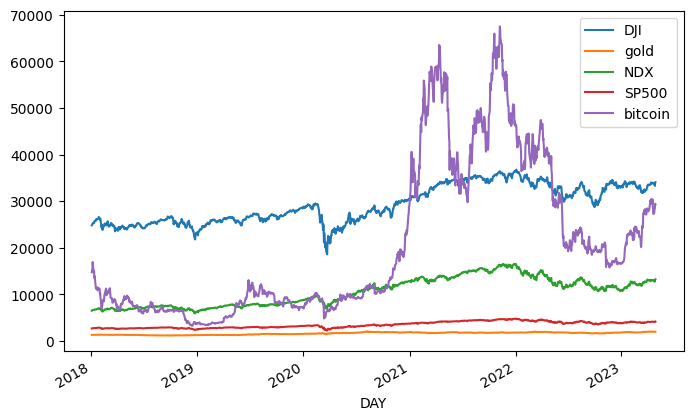

In [98]:
All_data.index = All_data['DAY']
All_data = All_data.drop(['DAY'], axis=1)   #특성변수
All_data.plot(figsize = (8,5))

In [99]:
print(All_data)

                 DJI    gold       NDX    SP500  bitcoin
DAY                                                     
2018-01-02  24824.01  1312.1   6511.34  2695.81  14754.1
2018-01-03  24922.68  1314.9   6575.80  2713.06  15156.6
2018-01-04  25075.13  1314.5   6584.58  2723.99  15180.1
2018-01-05  25295.87  1317.2   6653.29  2743.15  16954.8
2018-01-08  25283.00  1320.0   6676.63  2747.71  14976.2
...              ...     ...       ...      ...      ...
2023-04-24  33875.92  1978.2  12969.76  4137.04  27509.3
2023-04-25  33531.72  1987.4  12725.11  4071.63  28298.8
2023-04-26  33301.67  2003.0  12806.49  4055.99  28424.6
2023-04-27  33826.66  1985.7  13160.03  4135.35  29475.9
2023-04-28  34098.95  1982.6  13245.99  4169.48  29321.8

[1340 rows x 5 columns]


In [100]:
All_data = np.log(All_data)
All_data.head() # 스케일 조정? 변동성 최소화?하기 위한 로그변환??

,DJI,gold,NDX,SP500,bitcoin
DAY,,,,,
2018-01-02,10.119567,7.179384,8.781301,7.899454,9.599276
2018-01-03,10.123534,7.181516,8.791152,7.905832,9.626191
2018-01-04,10.129632,7.181212,8.792486,7.909853,9.627741
2018-01-05,10.138396,7.183264,8.802867,7.916862,9.738306
2018-01-08,10.137888,7.185387,8.806369,7.918523,9.614218


<Axes: xlabel='DAY'>

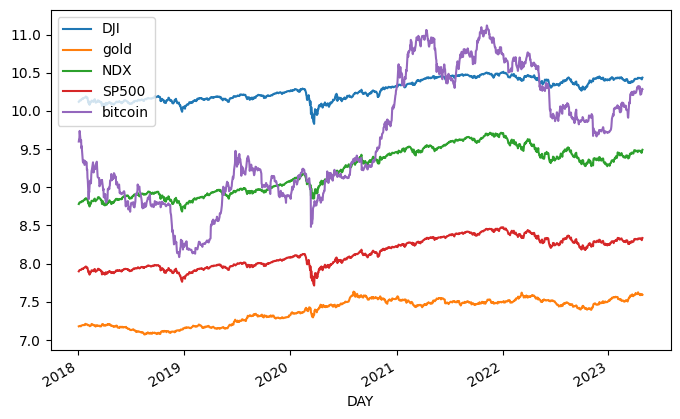

In [47]:
All_data.plot(figsize = (8,5))

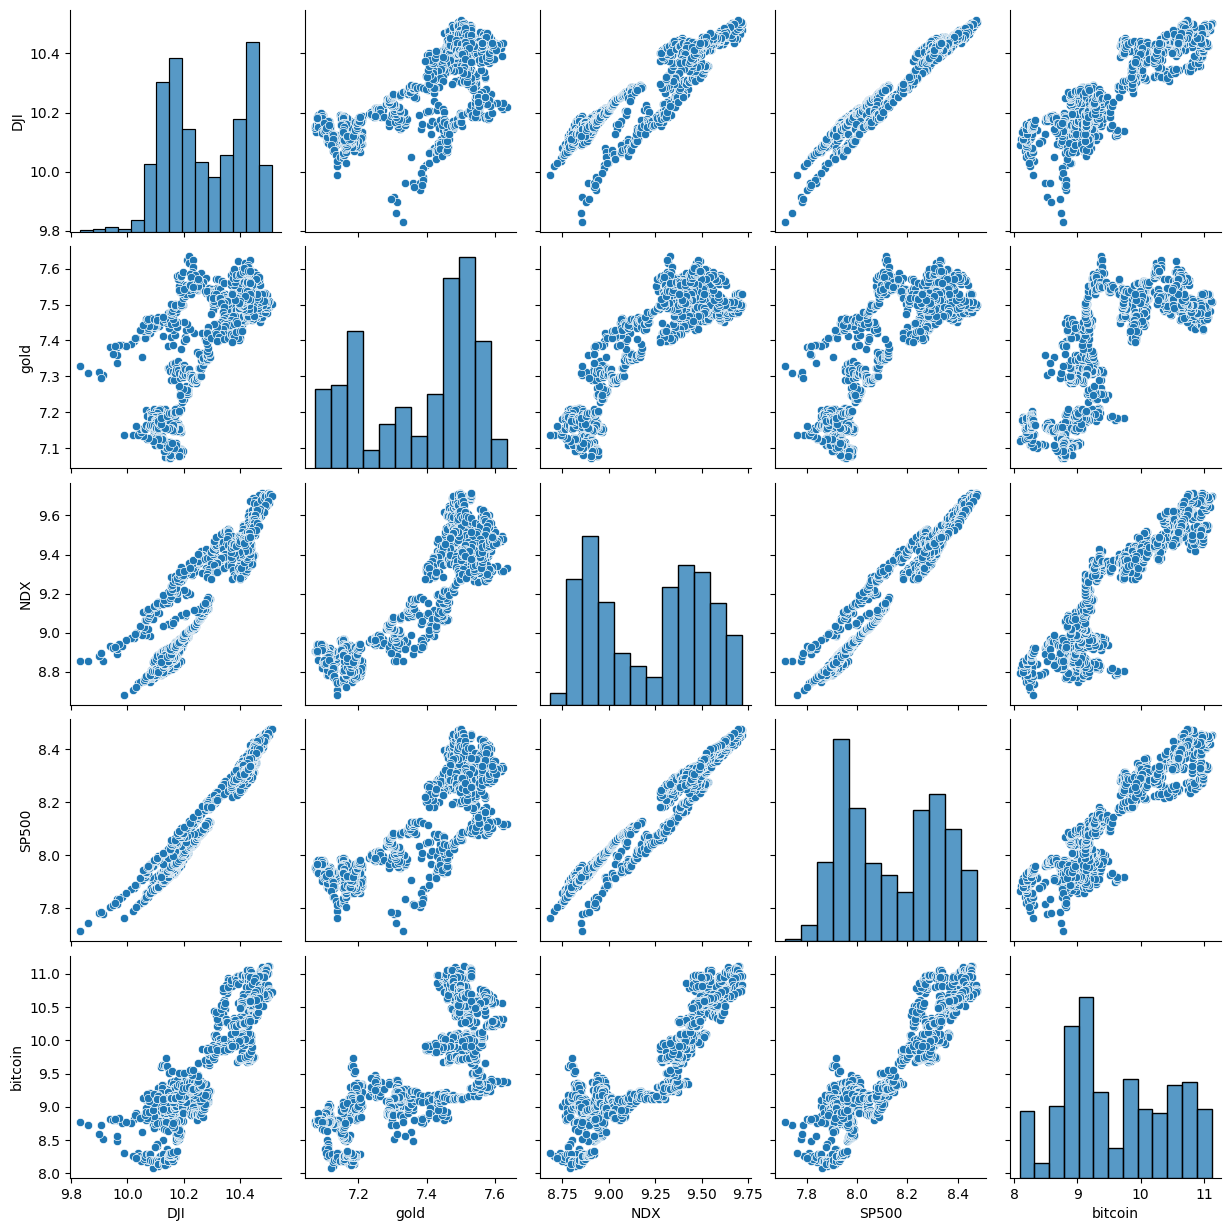

In [48]:
sns.pairplot(All_data) # 비교적 비트코인과 양의 상관관계를 가진다는 것을 확인?? 독립변수간에도 높은 선형관계?(다중공선성 생각?)

In [49]:
All_data.corr() # 상관계수가 강함??

,DJI,gold,NDX,SP500,bitcoin
DJI,1.000000,0.730763,0.916787,0.980614,0.892943
gold,0.730763,1.000000,0.882990,0.812422,0.758099
NDX,0.916787,0.882990,1.000000,0.972456,0.912929
SP500,0.980614,0.812422,0.972456,1.000000,0.923236
bitcoin,0.892943,0.758099,0.912929,0.923236,1.000000


### 각 독립 변수와 종속 변수의 관계 파악


In [50]:
x1 = All_data.DJI
x2 = All_data.gold
x3 = All_data.NDX
x4 = All_data.SP500
y = All_data.bitcoin
model = sm.OLS(y, x1)  # OLS 모델을 생성
DJIresults = model.fit()  # 모델을 적합
print(DJIresults.summary())  # 결과

                                 OLS Regression Results                                
Dep. Variable:                bitcoin   R-squared (uncentered):                   0.995
Model:                            OLS   Adj. R-squared (uncentered):              0.995
Method:                 Least Squares   F-statistic:                          2.551e+05
Date:                Mon, 27 Apr 2026   Prob (F-statistic):                        0.00
Time:                        23:48:56   Log-Likelihood:                         -1417.6
No. Observations:                1340   AIC:                                      2837.
Df Residuals:                    1339   BIC:                                      2842.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [51]:
model = sm.OLS(y, x2)  # OLS 모델을 생성
goldresults = model.fit()  # 모델을 적합
print(goldresults.summary())  # 결과

                                 OLS Regression Results                                
Dep. Variable:                bitcoin   R-squared (uncentered):                   0.995
Model:                            OLS   Adj. R-squared (uncentered):              0.995
Method:                 Least Squares   F-statistic:                          2.798e+05
Date:                Mon, 27 Apr 2026   Prob (F-statistic):                        0.00
Time:                        23:49:02   Log-Likelihood:                         -1356.0
No. Observations:                1340   AIC:                                      2714.
Df Residuals:                    1339   BIC:                                      2719.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [52]:
model = sm.OLS(y, x3)  # OLS 모델을 생성
NDXresults = model.fit()  # 모델을 적합
print(NDXresults.summary())  # 결과

                                 OLS Regression Results                                
Dep. Variable:                bitcoin   R-squared (uncentered):                   0.997
Model:                            OLS   Adj. R-squared (uncentered):              0.997
Method:                 Least Squares   F-statistic:                          4.168e+05
Date:                Mon, 27 Apr 2026   Prob (F-statistic):                        0.00
Time:                        23:49:25   Log-Likelihood:                         -1090.1
No. Observations:                1340   AIC:                                      2182.
Df Residuals:                    1339   BIC:                                      2187.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [53]:
model = sm.OLS(y, x4)  # OLS 모델을 생성합니다
SP500results = model.fit()  # 모델을 적합시킵니다
print(SP500results.summary())  # 결과를 출력합니다

                                 OLS Regression Results                                
Dep. Variable:                bitcoin   R-squared (uncentered):                   0.996
Model:                            OLS   Adj. R-squared (uncentered):              0.996
Method:                 Least Squares   F-statistic:                          3.346e+05
Date:                Mon, 27 Apr 2026   Prob (F-statistic):                        0.00
Time:                        23:50:17   Log-Likelihood:                         -1236.6
No. Observations:                1340   AIC:                                      2475.
Df Residuals:                    1339   BIC:                                      2480.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

### 목적변수 (Y: Target Variable)과  특성변수 (X: Charateristic variavle)의 분리


In [54]:
X = All_data.drop(['bitcoin'], axis=1)   #특성변수
Y = All_data['bitcoin'] #목표변수

In [55]:
print(X)

                  DJI      gold       NDX     SP500
DAY                                                
2018-01-02  10.119567  7.179384  8.781301  7.899454
2018-01-03  10.123534  7.181516  8.791152  7.905832
2018-01-04  10.129632  7.181212  8.792486  7.909853
2018-01-05  10.138396  7.183264  8.802867  7.916862
2018-01-08  10.137888  7.185387  8.806369  7.918523
...               ...       ...       ...       ...
2023-04-24  10.430460  7.589943  9.470376  8.327736
2023-04-25  10.420247  7.594583  9.451332  8.311799
2023-04-26  10.413363  7.602401  9.457707  8.307950
2023-04-27  10.429005  7.593727  9.484939  8.327327
2023-04-28  10.437022  7.592164  9.491450  8.335547

[1340 rows x 4 columns]


In [56]:
print(Y)

DAY
2018-01-02     9.599276
2018-01-03     9.626191
2018-01-04     9.627741
2018-01-05     9.738306
2018-01-08     9.614218
                ...    
2023-04-24    10.222279
2023-04-25    10.250575
2023-04-26    10.255010
2023-04-27    10.291328
2023-04-28    10.286087
Name: bitcoin, Length: 1340, dtype: float64


In [57]:
# OLS (최소자승법) 모델 피팅
model = sm.OLS(Y, X)
results = model.fit()

# 회귀 결과 요약 출력
print(results.summary()) ## 하나씩 대조했을 때는 다 유의확률이 0.005보다 작았으나 전체적으로 했을때, NDX의 유의확률이 0.245로 0.005보다 크게 나타남

                                 OLS Regression Results                                
Dep. Variable:                bitcoin   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          3.229e+05
Date:                Mon, 27 Apr 2026   Prob (F-statistic):                        0.00
Time:                        23:50:43   Log-Likelihood:                         -332.17
No. Observations:                1340   AIC:                                      672.3
Df Residuals:                    1336   BIC:                                      693.1
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [66]:
X.drop(['NDX'], axis=1, inplace=True) # NDX 제거

### 데이터 셋 설정

In [68]:
# 훈련 vs 테스트의 분리
X_train = X.loc[X.index < '2022-04-05',:] # 8대2 비율로 분리
X_test = X.loc[X.index > '2022-04-05',:]
print(X_train.shape,X_test.shape)

(1072, 3) (267, 3)


In [69]:
y_train = Y.loc[Y.index < '2022-04-05']
y_test = Y.loc[Y.index > '2022-04-05']
print(y_train.shape,y_test.shape)
print(y_train)

(1072,) (267,)
DAY
2018-01-02     9.599276
2018-01-03     9.626191
2018-01-04     9.627741
2018-01-05     9.738306
2018-01-08     9.614218
                ...    
2022-03-29    10.767411
2022-03-30    10.759497
2022-03-31    10.726017
2022-04-01    10.742832
2022-04-04    10.749978
Name: bitcoin, Length: 1072, dtype: float64


### 다중선형회귀모델 활용

In [75]:
#모형 추정을 위한 라이브러리의 객체화 및 회귀식 추정.
from sklearn.linear_model import LinearRegression

reg = LinearRegression()          # 라이브러리 세팅.

reg.fit(X_train, y_train)         # 모형의 적합

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
## 회귀 계수의 확인.
print('Slope:', reg.coef_)
print('Intercept:' ,reg.intercept_)

Slope: [-1.09404763 -0.04814458  4.94904738]
Intercept: -19.01978079692506


In [77]:
#예측치의 생성.
y_train_pred=reg.predict(X_train)
y_test_pred=reg.predict(X_test)

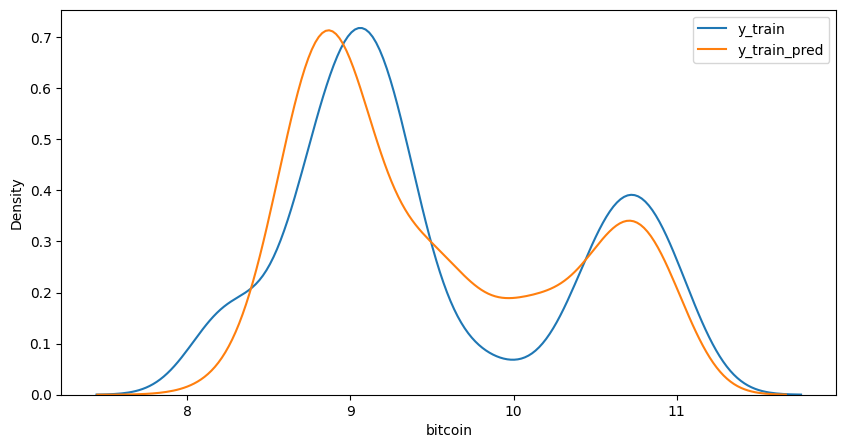

In [81]:
# 예측된 데이터와 실데이터를 kdeplot 으로 출력하기 # 비슷한 양상?
plt.figure(figsize=(10,5))
ax1 = sns.kdeplot(y_train, label="y_train")
ax2 = sns.kdeplot(y_train_pred, label='y_train_pred', ax=ax1)
plt.legend()
plt.show()

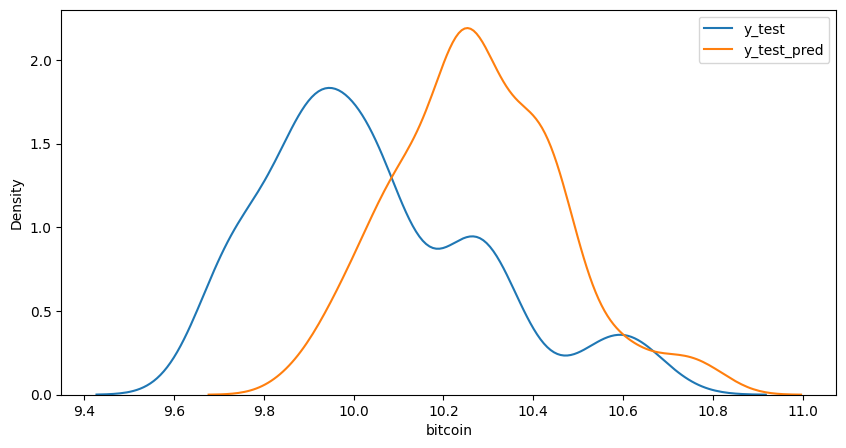

In [82]:
plt.figure(figsize=(10,5))
ax1 = sns.kdeplot(y_test, label="y_test")
ax2 = sns.kdeplot(y_test_pred, label='y_test_pred', ax=ax1) #
plt.legend()
plt.show() 
## 테스트 값이 훈련 값보다 덜 유사한 양상으로 나타남. 훈련 데이터로 모델을 적합했기 때문에 훈련 데이터에 대한 예측값이 실제값과 유사한 양상으로 나타나는 것은 비슷할 수 있지만, 테스트 데이터에 대한 예측값이 실제값과 유사한 양상으로 나타나지 않는 것은 모델의 일반화 능력이 떨어진다는 것을 의미할 수 있음.

In [83]:
#모형의 적합도 비교.
# MSE의 비교. # MSE = SSE
from sklearn.metrics import mean_squared_error
print('MSE train: %.3f, test: %.3f' % (
    mean_squared_error(y_train, y_train_pred),
    mean_squared_error(y_test, y_test_pred))) # 훈련 데이터에 대한 MSE는 0.102, 테스트 데이터에 대한 MSE는 0.083으로 나타남. 훈련 데이터에 대한 MSE가 테스트 데이터에 대한 MSE보다 더 큰 것은 모델이 훈련 데이터에 과적합(overfitting)되어 있을 가능성이 있음을 시사할 수 있음. 과적합은 모델이 훈련 데이터의 노이즈까지 학습하여 새로운 데이터에 대한 예측 성능이 떨어지는 현상임.


MSE train: 0.102, test: 0.083


In [84]:
# 결정계수의 비교.
from sklearn.metrics import r2_score
print('R^2 Train: %.3f, test: %.3f' %(r2_score(y_train, y_train_pred),
                                      r2_score(y_test, y_test_pred))) 
# 훈련 데이터에 대한 결정계수는 0.863, 테스트 데이터에 대한 결정계수는 -0.408로 나타남

R^2 Train: 0.863, test: -0.408


### 이후 규제를 넣었을 때 라쏘 릿지 엘라스틱넷을 넣어 판단

In [85]:
#릿지
from sklearn.linear_model import Ridge
## alpha(규제의 강도) 값을 늘려가며 훈련하기 (하이퍼파라미터)

train_score =[]
test_score=[]

alpha_list = [0.001,0.01,0.1,1,10,100]
for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_train_pred=ridge.predict(X_train)
    y_test_pred=ridge.predict(X_test)
    train_score.append(ridge.score(X_train,y_train))
    test_score.append(ridge.score(X_test,y_test))   ### 100 일때 가장 괜찮게 나옴 그렇지만 너무 낮음
    print("alpha 값:",alpha)
    print('MSE train: %.3f, test: %.3f' % (
    mean_squared_error(y_train, y_train_pred),
    mean_squared_error(y_test, y_test_pred)))

    print('R^2 train: %.3f, test: %.3f' %(r2_score(y_train, y_train_pred),
                                      r2_score(y_test, y_test_pred)))

    print(" ") # 무의미

alpha 값: 0.001
MSE train: 0.102, test: 0.083
R^2 train: 0.863, test: -0.410
 
alpha 값: 0.01
MSE train: 0.102, test: 0.084
R^2 train: 0.863, test: -0.426
 
alpha 값: 0.1
MSE train: 0.103, test: 0.091
R^2 train: 0.863, test: -0.551
 
alpha 값: 1
MSE train: 0.105, test: 0.105
R^2 train: 0.860, test: -0.783
 
alpha 값: 10
MSE train: 0.116, test: 0.072
R^2 train: 0.844, test: -0.228
 
alpha 값: 100
MSE train: 0.310, test: 0.071
R^2 train: 0.584, test: -0.209
 


In [86]:
### 엘라스틱넷

from sklearn.linear_model import ElasticNet
train_score =[]
test_score=[]

alpha_list = [0.001,0.01,0.1,1,10,100]
ratios = [0,0.2,0.5,0.7,1]
for alpha in alpha_list:
    for ratio in ratios:
        elasticnet = ElasticNet(alpha=alpha,l1_ratio=ratio)
        elasticnet.fit(X_train, y_train)
        y_train_pred=elasticnet.predict(X_train)
        y_test_pred=elasticnet.predict(X_test)
        train_score.append(elasticnet.score(X_train,y_train))
        test_score.append(elasticnet.score(X_test,y_test))

        print("alpha 값:",alpha,"l1_ratio 값:",ratio)
        print('MSE train: %.3f, test: %.3f' % (
        mean_squared_error(y_train, y_train_pred),
        mean_squared_error(y_test, y_test_pred)))

        print('R^2 train: %.3f, test: %.3f' %(r2_score(y_train, y_train_pred),
                                              r2_score(y_test, y_test_pred)))

        print(" ") # 무의미
    

e:\project_in_progess\BitGoldEquity_project1\BitGoldEquity_project1\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.140e+01, tolerance: 7.999e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
e:\project_in_progess\BitGoldEquity_project1\BitGoldEquity_project1\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.985e+01, tolerance: 7.999e-02
Linear regression models with a zero l1 penalization strength are mor

alpha 값: 0.001 l1_ratio 값: 0
MSE train: 0.105, test: 0.105
R^2 train: 0.860, test: -0.783
 
alpha 값: 0.001 l1_ratio 값: 0.2
MSE train: 0.104, test: 0.104
R^2 train: 0.860, test: -0.760
 
alpha 값: 0.001 l1_ratio 값: 0.5
MSE train: 0.104, test: 0.100
R^2 train: 0.861, test: -0.693
 
alpha 값: 0.001 l1_ratio 값: 0.7
MSE train: 0.103, test: 0.094
R^2 train: 0.862, test: -0.602
 
alpha 값: 0.001 l1_ratio 값: 1
MSE train: 0.103, test: 0.092
R^2 train: 0.862, test: -0.552
 
alpha 값: 0.01 l1_ratio 값: 0
MSE train: 0.118, test: 0.070
R^2 train: 0.842, test: -0.190
 
alpha 값: 0.01 l1_ratio 값: 0.2
MSE train: 0.116, test: 0.072
R^2 train: 0.845, test: -0.219
 
alpha 값: 0.01 l1_ratio 값: 0.5
MSE train: 0.113, test: 0.074
R^2 train: 0.849, test: -0.251
 
alpha 값: 0.01 l1_ratio 값: 0.7
MSE train: 0.110, test: 0.073
R^2 train: 0.852, test: -0.241
 
alpha 값: 0.01 l1_ratio 값: 1
MSE train: 0.106, test: 0.070
R^2 train: 0.858, test: -0.194
 
alpha 값: 0.1 l1_ratio 값: 0
MSE train: 0.322, test: 0.077
R^2 train: 0.568

### 검색을 통해 VAR모델도 있다는 것을 알게 됨(선형 모델이외의 모델 수행)


In [91]:
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

In [101]:
## tationary라는 뜻은 정적이라는 뜻이다. 또한 stationarity라 정상성이란 뜻인데, 데이터가 정상성을 가진다는 의미는 데이터의 평균과 분산이 안정되어 있어 분석하기 쉽다는 의미이기도 하다.
# 평균이 일정하지 않으면 차분을 취하고, 분산이 일정하지 않으면 변환을 취함
# VAR을 적용시켜보기 전에 두 시계열 변수가 모두 stationay 상태이어야 한다.

All_data = np.exp(All_data)
indices = ['DJI', 'gold', 'NDX', 'SP500', 'bitcoin'] 
for index in indices:
    ## stationary라는 뜻은 정적이라는 뜻이다. 또한 stationarity라 정상성이란 뜻인데, 데이터가 정상성을 가진다는 의미는 데이터의 평균과 분산이 안정되어 있어 분석하기 쉽다는 의미이기도 하다.
    # 평균이 일정하지 않으면 차분을 취하고, 분산이 일정하지 않으면 변환을 취함
    # VAR을 적용시켜보기 전에 두 시계열 변수가 모두 stationay 상태이어야 한다.

    indices = ['DJI', 'gold', 'NDX', 'SP500', 'bitcoin']
    for index in indices:
        adfuller_test = adfuller(All_data[index], autolag="AIC")
        print("{} ADF test statistic: {}".format(index, adfuller_test[0]))
        print("p-value: {}".format(adfuller_test[1]))

DJI ADF test statistic: -1.4050516680917156
p-value: 0.5798519034392902
gold ADF test statistic: -0.8469150079139277
p-value: 0.8049513759606282
NDX ADF test statistic: -1.1701859331848836
p-value: 0.6862877218179062
SP500 ADF test statistic: -1.1382688838555393
p-value: 0.6995720388923139
bitcoin ADF test statistic: -1.7081203253676305
p-value: 0.4269335722867956
DJI ADF test statistic: -1.4050516680917156
p-value: 0.5798519034392902
gold ADF test statistic: -0.8469150079139277
p-value: 0.8049513759606282
NDX ADF test statistic: -1.1701859331848836
p-value: 0.6862877218179062
SP500 ADF test statistic: -1.1382688838555393
p-value: 0.6995720388923139
bitcoin ADF test statistic: -1.7081203253676305
p-value: 0.4269335722867956
DJI ADF test statistic: -1.4050516680917156
p-value: 0.5798519034392902
gold ADF test statistic: -0.8469150079139277
p-value: 0.8049513759606282
NDX ADF test statistic: -1.1701859331848836
p-value: 0.6862877218179062
SP500 ADF test statistic: -1.1382688838555393
p-v

In [102]:
All_data_diff = All_data.diff().dropna() ## 정상성을 확보하기 위해 차분을 시행

In [103]:
for index in indices:
    indices = ['DJI', 'gold', 'NDX', 'SP500', 'bitcoin']
    for index in indices:
        adfuller_test = adfuller(All_data[index], autolag="AIC")
        print("{} ADF test statistic: {}".format(index, adfuller_test[0]))
        print("p-value: {}".format(adfuller_test[1]))  ## P-value 값이 낮아진 걸 확인 할 수 있음?

DJI ADF test statistic: -1.4050516680917156
p-value: 0.5798519034392902
gold ADF test statistic: -0.8469150079139277
p-value: 0.8049513759606282
NDX ADF test statistic: -1.1701859331848836
p-value: 0.6862877218179062
SP500 ADF test statistic: -1.1382688838555393
p-value: 0.6995720388923139
bitcoin ADF test statistic: -1.7081203253676305
p-value: 0.4269335722867956
DJI ADF test statistic: -1.4050516680917156
p-value: 0.5798519034392902
gold ADF test statistic: -0.8469150079139277
p-value: 0.8049513759606282
NDX ADF test statistic: -1.1701859331848836
p-value: 0.6862877218179062
SP500 ADF test statistic: -1.1382688838555393
p-value: 0.6995720388923139
bitcoin ADF test statistic: -1.7081203253676305
p-value: 0.4269335722867956
DJI ADF test statistic: -1.4050516680917156
p-value: 0.5798519034392902
gold ADF test statistic: -0.8469150079139277
p-value: 0.8049513759606282
NDX ADF test statistic: -1.1701859331848836
p-value: 0.6862877218179062
SP500 ADF test statistic: -1.1382688838555393
p-v

In [104]:
train = All_data_diff.iloc[:-100,:]
test = All_data_diff.iloc[-100:,:] # 마지막 10일을 기준으로 셋을 나눈다?

In [105]:
forecasting_model = VAR(train)
results_aic = []
for p in range(1,30):   #30번 시행
  results = forecasting_model.fit(p)
  results_aic.append(results.aic)

e:\project_in_progess\BitGoldEquity_project1\BitGoldEquity_project1\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


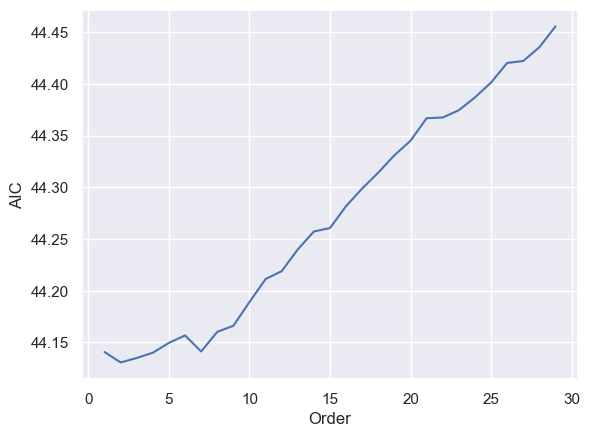

In [106]:
sns.set()
plt.plot(list(np.arange(1,30,1)), results_aic)
plt.xlabel("Order")
plt.ylabel("AIC")
plt.show() # 2일때 가장 낮은 값을 보임

In [107]:
results = forecasting_model.fit(2)
results.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 28, Apr, 2026
Time:                     00:13:11
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    44.3584
Nobs:                     1237.00    HQIC:                   44.2163
Log likelihood:          -36016.0    FPE:                1.46461e+19
AIC:                      44.1307    Det(Omega_mle):     1.40119e+19
--------------------------------------------------------------------
Results for equation DJI
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              7.199462        10.097559            0.713           0.476
L1.DJI            -0.132554         0.140440           -0.944           0.345
L1.gold           -0.620465         0.652782           -0.950           0.

In [108]:
laaged_values = train.values[-2:]
forecast = pd.DataFrame(results.forecast(y= laaged_values, steps=100), index = test.index, columns= ['DJI_1d','gold_1d','NDX_1d','SP500_1d','bitcoin_1d'])
forecast

,DJI_1d,gold_1d,NDX_1d,SP500_1d,bitcoin_1d
DAY,,,,,
2022-12-05,98.049917,3.232286,45.388850,11.471395,65.009252
2022-12-06,-41.170046,-0.571623,-15.585450,-4.450362,-23.256729
2022-12-07,32.051870,0.721144,12.285643,3.802661,3.636344
2022-12-08,-3.297859,0.197082,0.683691,-0.124208,1.541942
2022-12-09,11.935507,0.476475,6.130923,1.604291,1.530219
...,...,...,...,...,...
2023-04-24,7.603257,0.381105,4.393982,1.094356,1.562305
2023-04-25,7.603257,0.381105,4.393982,1.094356,1.562305
2023-04-26,7.603257,0.381105,4.393982,1.094356,1.562305


In [109]:
forecast["DJI_forecasted"] = All_data["DJI"].iloc[-10-1] + forecast['DJI_1d'].cumsum()
forecast["gold_forecasted"] = All_data["gold"].iloc[-10-1] + forecast['gold_1d'].cumsum()
forecast["NDX_forecasted"] = All_data["NDX"].iloc[-10-1] + forecast['NDX_1d'].cumsum()
forecast["SP500_forecasted"] = All_data["SP500"].iloc[-10-1] + forecast['SP500_1d'].cumsum()
forecast["bitcoin_forecasted"] = All_data["bitcoin"].iloc[-10-1] + forecast['bitcoin_1d'].cumsum()
forecast # 데이터 비교를 위해 차분 전을 가지고 옴

,DJI_1d,gold_1d,NDX_1d,SP500_1d,bitcoin_1d,DJI_forecasted,gold_forecasted,NDX_forecasted,SP500_forecasted,bitcoin_forecasted
DAY,,,,,,,,,,
2022-12-05,98.049917,3.232286,45.388850,11.471395,65.009252,33983.359917,2022.632286,13124.908850,4149.111395,30537.509252
2022-12-06,-41.170046,-0.571623,-15.585450,-4.450362,-23.256729,33942.189871,2022.060662,13109.323400,4144.661033,30514.252523
2022-12-07,32.051870,0.721144,12.285643,3.802661,3.636344,33974.241741,2022.781807,13121.609043,4148.463693,30517.888867
2022-12-08,-3.297859,0.197082,0.683691,-0.124208,1.541942,33970.943883,2022.978889,13122.292735,4148.339485,30519.430809
2022-12-09,11.935507,0.476475,6.130923,1.604291,1.530219,33982.879389,2023.455364,13128.423658,4149.943776,30520.961027
...,...,...,...,...,...,...,...,...,...,...
2023-04-24,7.603257,0.381105,4.393982,1.094356,1.562305,34673.418467,2058.105558,13527.739940,4249.370444,30663.085580
2023-04-25,7.603257,0.381105,4.393982,1.094356,1.562305,34681.021724,2058.486662,13532.133921,4250.464799,30664.647884
2023-04-26,7.603257,0.381105,4.393982,1.094356,1.562305,34688.624981,2058.867767,13536.527903,4251.559155,30666.210189


<Axes: xlabel='DAY'>

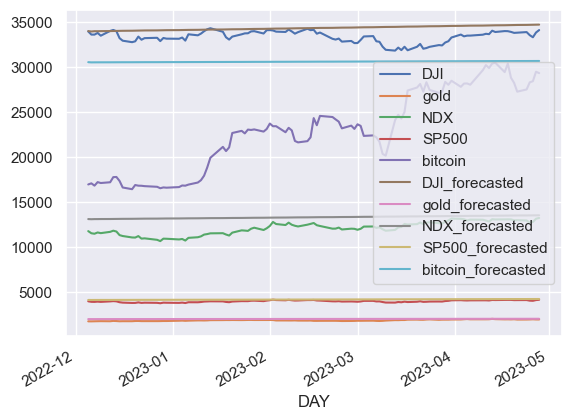

In [ ]:
test = All_data.iloc[-100:,:]
test["DJI_forecasted"] = forecast["DJI_forecasted"]
test["gold_forecasted"] = forecast["gold_forecasted"]
test["NDX_forecasted"] = forecast["NDX_forecasted"]
test["SP500_forecasted"] = forecast["SP500_forecasted"]
test["bitcoin_forecasted"] = forecast["bitcoin_forecasted"]
test.plot() # 100일간의 데이터를 확인하였을 때 비슷한 추세를 나타내는 것을 확인할 수 있음?? ㄴㄴ